# Plot RIO Statistics Along Route (Unstructured Grid)

This notebook creates contour maps of RIO (Risk Index Outcome) values for specific vessel types and overlays:
1. Route points (transect of interest)
2. MPAS-SI mesh points used for interpolation

**Key difference from structured version**: Uses direct unstructured contouring (`tricontourf`) on the native MPAS mesh without intermediate interpolation to a regular grid. This avoids artifacts from regridding and is more faithful to the original data.

In [19]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cols
import xarray
import os
from scipy.spatial import KDTree

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.tri as mtri
import cmocean

In [20]:
# Configuration and parameters
years = ['2000']
months = ['05']
classes = ['PC6']  # Vessel type

# RIO statistic to plot: 'median', '5th', or '95th'
rio_statistic = '95th'  # Options: 'median', '5th', '95th'

# File paths
pathBase = '/Users/stephenprice/projects/CINS/ColdHarbor/test-data/v3.LR.historical_seaIceRIO_ensembleStats'
prefix = 'v3.LR.historical_'
mpassiPrefix = '.mpassi.hist.am.timeSeriesStatsDaily.'

# Map output path
mapPath = '/Users/stephenprice/projects/CINS/ColdHarbor/maps'

# Conversion factor
rad2deg = 180.0 / np.pi

In [21]:
# Load MPAS-O mesh lat/lon coordinates
os.chdir(pathBase)
fileIn = '../mpaso-IcoswISC30E3r5-restart.nc'
ds = xarray.open_dataset(fileIn)

lat_mesh = ds.latCell.values * rad2deg
lon_mesh = ds.lonCell.values * rad2deg

# Convert longitude values to same format as route definitions (-180 to 180)
lon_mesh_temp = np.zeros(np.shape(lon_mesh))
for i in np.arange(0, np.size(lon_mesh)):
    if lon_mesh[i] > 180:
        lon_mesh_temp[i] = lon_mesh[i] - 360
    else:
        lon_mesh_temp[i] = lon_mesh[i]

lon_mesh = lon_mesh_temp
del lon_mesh_temp

# Filter to Northern region (>= 60°N) if using reduced area data
ind = np.where(lat_mesh >= 60.0)[0]
lat_mesh = lat_mesh[ind]
lon_mesh = lon_mesh[ind]

print(f"Loaded {len(lat_mesh)} mesh points")

Loaded 22076 mesh points


In [22]:
# Load route track data
fileIn = '../arctic_route_sections.nc'
ds = xarray.open_dataset(fileIn)

# Extract route sections (using EJCD route combination as example)
lat_E = ds.lat_E.values
lon_E = ds.lon_E.values
dis_E = ds.dis_E.values

lat_J = ds.lat_J.values
lon_J = ds.lon_J.values
dis_J = ds.dis_J.values

lat_C = ds.lat_C.values
lon_C = ds.lon_C.values
dis_C = ds.dis_C.values

lat_D = ds.lat_D.values
lon_D = ds.lon_D.values
dis_D = ds.dis_D.values

# Combine route sections into single transect
trans_lat = np.hstack((lat_E, lat_J, lat_C, lat_D))
trans_lon = np.hstack((lon_E, lon_J, lon_C, lon_D))
trans_dist = np.hstack((dis_E, dis_J, dis_C, dis_D))

print(f"Loaded route with {len(trans_lat)} points")

Loaded route with 4216 points


In [23]:
# Find nearest neighbor mesh points for each route point
# Build KDTree for efficient spatial queries
tree = KDTree(list(zip(lon_mesh.flatten(), lat_mesh.flatten())))

# Query for k nearest neighbors
kneighbor = 4
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k=kneighbor)

print(f"Found {kneighbor} nearest neighbors for each of {len(trans_lat)} route points")

Found 4 nearest neighbors for each of 4216 route points


In [24]:
# Load RIO ensemble statistics for specified vessel type
os.chdir(pathBase)

year = years[0]
month = months[0]
cs = classes[0]

fileIn = prefix + cs + '_EnsStats' + mpassiPrefix + year + '-' + month + '-01.nc'
print(f'Reading RIO data from: {fileIn}')
dataIn = xarray.open_dataset(fileIn)

# Extract RIO values based on selected statistic
if rio_statistic == 'median':
    RIOData = dataIn.timeDaily_avg_RIO_ensembleMedian.values
    stat_label = 'Median'
elif rio_statistic == '5th':
    RIOData = dataIn.timeDaily_avg_RIO_ensemble5th.values
    stat_label = '5th Percentile'
elif rio_statistic == '95th':
    RIOData = dataIn.timeDaily_avg_RIO_ensemble95th.values
    stat_label = '95th Percentile'
else:
    raise ValueError(f"Invalid statistic: {rio_statistic}. Choose 'median', '5th', or '95th'")

ndays = np.size(RIOData, axis=0)
ncells = np.size(RIOData, axis=1)

print(f"Loaded RIO {stat_label} data: {ndays} days, {ncells} cells")

Reading RIO data from: v3.LR.historical_PC6_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2000-05-01.nc
Loaded RIO 95th Percentile data: 31 days, 22076 cells


In [25]:
# Define plotting function using unstructured contouring
def plot_rio_unstructured(lon_mesh, lat_mesh, RIO, trans_lon, trans_lat,
                          inds, vessel_type, stat_label='Median',
                          time_index=15, extent=(-180, 180, 65, 90),
                          vmin=-20.0, vmax=30.0, level_step=2.0,
                          cmap=cmocean.cm.tempo, max_edge_m=500_000,
                          figsize=(20, 20), dpi=300):
    """
    Create contour map of RIO data using unstructured triangulation.

    Coordinates are projected into NorthPolarStereo space (metres) before
    triangulation. This avoids antimeridian-wrapping artefacts from Delaunay
    in lon/lat space, and the known issue where passing a pre-built
    Triangulation to Cartopy tricontourf with transform= produces wrong results.
    """
    noProj  = ccrs.PlateCarree()
    mapProj = ccrs.NorthPolarStereo(central_longitude=0)

    # 1D arrays
    lon1 = np.asarray(lon_mesh).ravel()
    lat1 = np.asarray(lat_mesh).ravel()
    z1   = np.asarray(RIO)[time_index, :].ravel()

    # Drop NaNs
    good = np.isfinite(lon1) & np.isfinite(lat1) & np.isfinite(z1)
    lon1, lat1, z1 = lon1[good], lat1[good], z1[good]

    # Project lon/lat -> metres in NorthPolarStereo
    pts = mapProj.transform_points(noProj, lon1, lat1)
    xp, yp = pts[:, 0], pts[:, 1]

    # Drop any points that fail to project
    good_proj = np.isfinite(xp) & np.isfinite(yp)
    xp, yp, z1 = xp[good_proj], yp[good_proj], z1[good_proj]

    # Build Delaunay triangulation in projected (metric) space
    tri = mtri.Triangulation(xp, yp)

    # Mask large sliver triangles at the domain boundary
    verts = tri.triangles
    x0, x1, x2 = xp[verts[:, 0]], xp[verts[:, 1]], xp[verts[:, 2]]
    y0, y1, y2 = yp[verts[:, 0]], yp[verts[:, 1]], yp[verts[:, 2]]
    e0 = np.hypot(x1 - x0, y1 - y0)
    e1 = np.hypot(x2 - x1, y2 - y1)
    e2 = np.hypot(x0 - x2, y0 - y2)
    tri.set_mask(np.max(np.column_stack([e0, e1, e2]), axis=1) > max_edge_m)

    # Figure / axes
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax  = plt.axes(projection=mapProj)
    ax.set_extent(extent, crs=noProj)
    ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                 color='w', linestyle=':', zorder=50)

    # Filled contours — NO transform= because data is already in projection coords
    clevels = np.arange(vmin, vmax + 0.5 * level_step, level_step)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_under('white')
    cf = ax.tricontourf(tri, z1, levels=clevels, cmap=cmap_obj,
                        extend='both', zorder=5)

    cbar = plt.colorbar(cf, ax=ax, shrink=0.75, pad=0.03, orientation='vertical')
    cbar.set_label(f'RIO {stat_label}', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    # Route points (red) — in lon/lat so DO need transform
    ax.plot(np.asarray(trans_lon), np.asarray(trans_lat),
            linestyle='None', marker='.', markersize=3, color='red',
            transform=noProj, zorder=60, label='Route points')

    # Mesh interpolation points (black)
    inds_use  = np.asarray(inds)[:, 1:]
    flat_inds = np.unique(inds_use.ravel())
    ax.plot(np.asarray(lon_mesh)[flat_inds],
            np.asarray(lat_mesh)[flat_inds],
            linestyle='None', marker='.', markersize=0.5,
            markerfacecolor='none', color='black',
            transform=noProj, zorder=61, label='Mesh points')

    # Land / coastlines on top
    ax.add_feature(cfeature.LAND,      facecolor='0.85', edgecolor='none', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,                      zorder=101)
    ax.add_feature(cfeature.LAKES,     facecolor='0.85', edgecolor='none', zorder=100)

    ax.set_title(
        f'RIO {stat_label} - Vessel Type: {vessel_type}, Day: {time_index+1} (Unstructured)',
        fontsize=16, weight='bold')

    return fig, ax

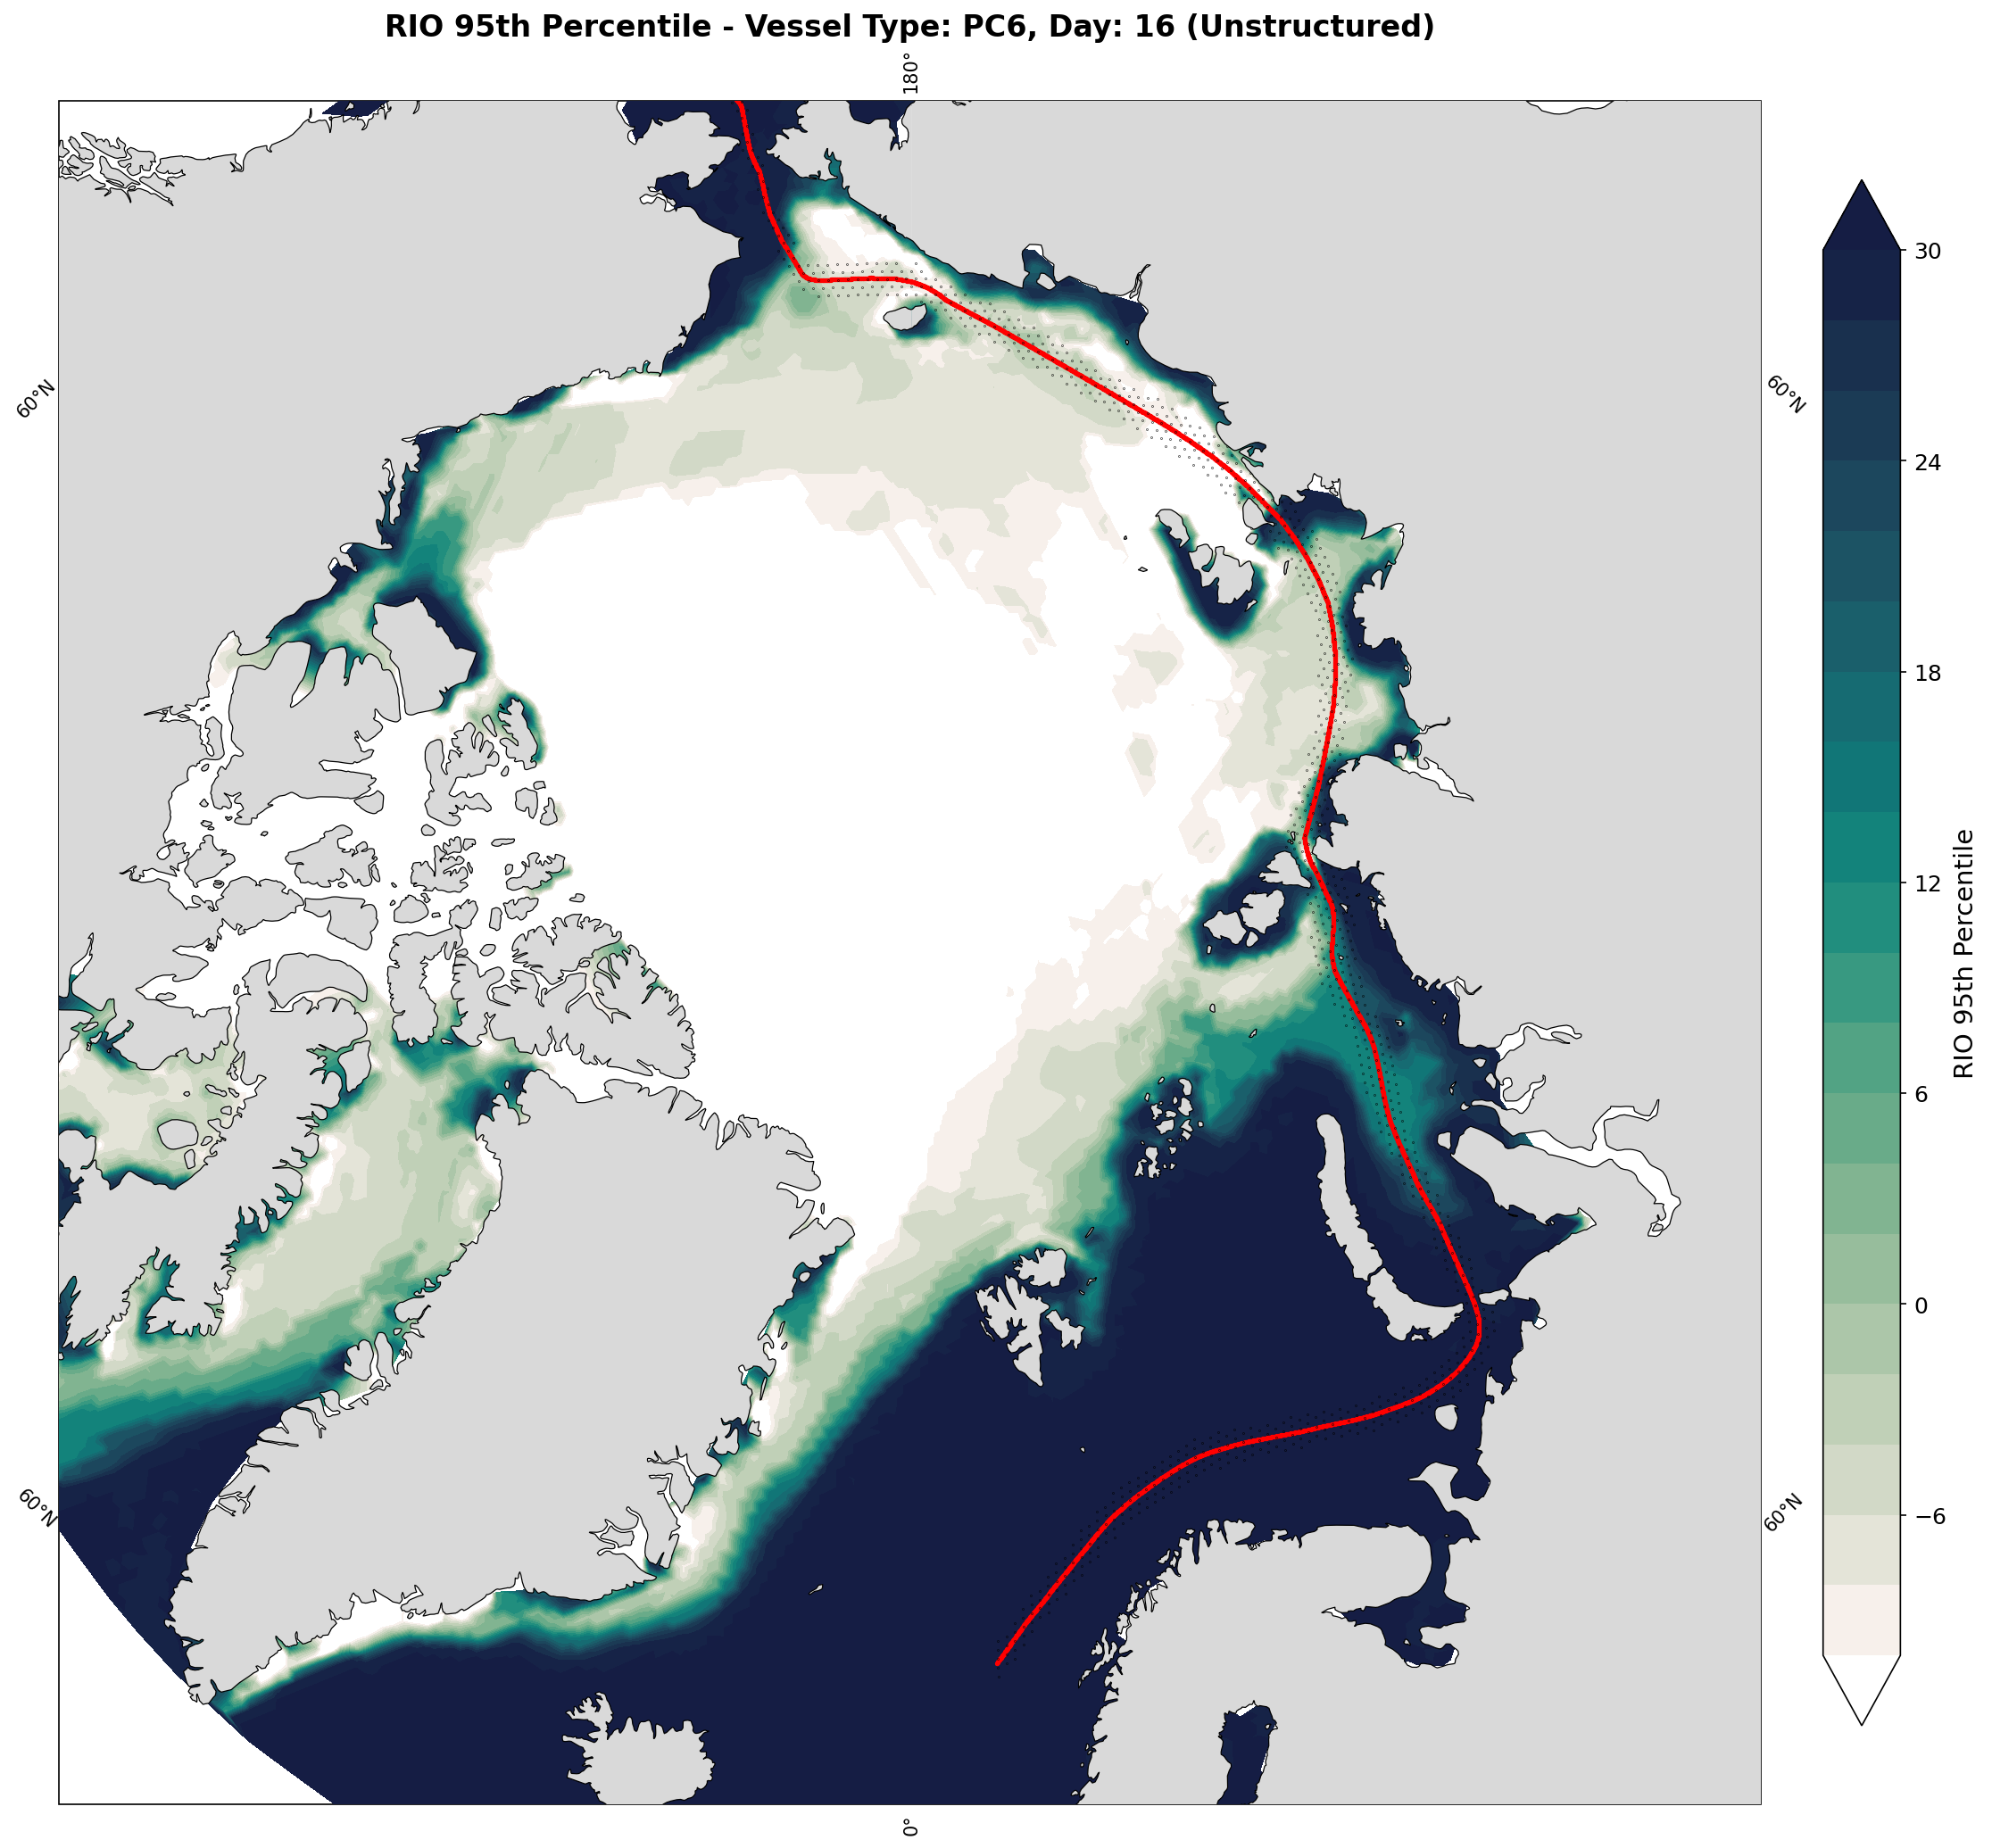

In [26]:
# Create the plot with overlays using unstructured contouring
time_index = 15  # Day 16 of the month
extent = (-180, 180, 65, 90)  # Arctic region

fig, ax = plot_rio_unstructured(
    lon_mesh=lon_mesh,
    lat_mesh=lat_mesh,
    RIO=RIOData,
    trans_lon=trans_lon,
    trans_lat=trans_lat,
    inds=inds,
    vessel_type=cs,
    stat_label=stat_label,
    time_index=time_index,
    extent=extent,
    vmin=-10,
    vmax=30,
    level_step=2,
    cmap=cmocean.cm.tempo,
    figsize=(20, 20),
    dpi=150  # Reduced for faster display
)

plt.show()

In [27]:
# Optional: Save figure to file
os.chdir(mapPath)
output_filename = f'RIO_map_unstruc_{rio_statistic}_{cs}_{year}-{month}_day{time_index+1}.png'
fig.savefig(output_filename, bbox_inches='tight', dpi=300)
print(f'Figure saved to: {mapPath}/{output_filename}')

Figure saved to: /Users/stephenprice/projects/CINS/ColdHarbor/maps/RIO_map_unstruc_95th_PC6_2000-05_day16.png


## Customization Options

To modify the visualization, you can adjust:

### RIO Statistic
Change `rio_statistic` to select which ensemble statistic to plot:
- `'median'` - Ensemble median (central tendency)
- `'5th'` - 5th percentile (lower bound of uncertainty)
- `'95th'` - 95th percentile (upper bound of uncertainty)

### Vessel Types
Change `classes = ['NIS']` to any of: `'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'IAsuper', 'IA', 'IB', 'IC', 'NIS'`

### Time Period
- Modify `years` list (e.g., `['2000', '2001', '2002']`)
- Modify `months` list (e.g., `['01', '02', '03']`)
- Change `time_index` to select different day (0-30)

### Route Selection
Modify the route combination in the "Load route track data" cell:
- Current: `(E, J, C, D)` sections
- Alternative example: `(A, B, I, H)` sections

### Map Appearance
In the plotting call, adjust:
- `extent`: Map boundaries (lon_min, lon_max, lat_min, lat_max)
- `vmin`, `vmax`: Color scale range
- `level_step`: Contour interval
- `cmap`: Color scheme (try `cmocean.cm.ice`, `cmocean.cm.balance`, etc.)
- `figsize`, `dpi`: Figure dimensions and resolution

## Key Advantages of Unstructured Approach

1. **No interpolation artifacts** - Contours are based directly on the MPAS mesh data
2. **More accurate** - Preserves the native data structure without regridding
3. **Better edge handling** - Uses `extend='both'` to properly handle values outside the range
4. **Faster** - Skips the intermediate interpolation step
5. **Respects mesh geometry** - Natural Delaunay triangulation of the unstructured grid